In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()  # choose marketing_campaign_dataset.csv

Saving marketing_campaign_dataset.csv to marketing_campaign_dataset.csv


In [2]:
df = pd.read_csv("marketing_campaign_dataset.csv")
print("Raw shape:", df.shape)
df.head()

Raw shape: (200000, 16)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [3]:
df["Acquisition_Cost"] = df["Acquisition_Cost"].replace(r"[\$,]", "", regex=True).astype(float)
df["Duration_Days"] = df["Duration"].str.extract(r"(\d+)").astype(int)
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Quarter"] = df["Date"].dt.quarter
df["Conversion_Rate_Pct"] = df["Conversion_Rate"] * 100

print("Nulls:\n", df.isnull().sum())
print("Duplicate Campaign_IDs:", df.duplicated(subset=["Campaign_ID"]).sum())
df = df.drop_duplicates(subset=["Campaign_ID"])

Nulls:
 Campaign_ID            0
Company                0
Campaign_Type          0
Target_Audience        0
Duration               0
Channel_Used           0
Conversion_Rate        0
Acquisition_Cost       0
ROI                    0
Location               0
Language               0
Clicks                 0
Impressions            0
Engagement_Score       0
Customer_Segment       0
Date                   0
Duration_Days          0
Year                   0
Month                  0
Month_Name             0
Quarter                0
Conversion_Rate_Pct    0
dtype: int64
Duplicate Campaign_IDs: 0


In [4]:
df["Revenue_Generated"] = df["ROI"] * df["Acquisition_Cost"]
df["Net_Profit"] = df["Revenue_Generated"] - df["Acquisition_Cost"]
df["CTR_Pct"] = (df["Clicks"] / df["Impressions"]) * 100
df["Cost_Per_Click"] = df["Acquisition_Cost"] / df["Clicks"]
df["Est_Conversions"] = (df["Clicks"] * df["Conversion_Rate"]).round(0)
df["Cost_Per_Conversion"] = np.where(df["Est_Conversions"] > 0, df["Acquisition_Cost"] / df["Est_Conversions"], np.nan)

def roi_bucket(x):
    if x < 3: return "Low ROI (<3x)"
    elif x < 6: return "Medium ROI (3x-6x)"
    else: return "High ROI (6x+)"

df["ROI_Bucket"] = df["ROI"].apply(roi_bucket)

cols = ["Campaign_ID","Company","Campaign_Type","Target_Audience","Duration","Duration_Days",
        "Channel_Used","Conversion_Rate","Conversion_Rate_Pct","Acquisition_Cost","ROI","ROI_Bucket",
        "Revenue_Generated","Net_Profit","Location","Language","Clicks","Impressions","CTR_Pct",
        "Cost_Per_Click","Est_Conversions","Cost_Per_Conversion","Engagement_Score","Customer_Segment",
        "Date","Year","Month","Month_Name","Quarter"]
df = df[cols]
print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (200000, 29)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Duration_Days,Channel_Used,Conversion_Rate,Conversion_Rate_Pct,Acquisition_Cost,...,Cost_Per_Click,Est_Conversions,Cost_Per_Conversion,Engagement_Score,Customer_Segment,Date,Year,Month,Month_Name,Quarter
0,1,Innovate Industries,Email,Men 18-24,30 days,30,Google Ads,0.04,4.0,16174.0,...,31.964427,20.0,808.700000,6,Health & Wellness,2021-01-01,2021,1,Jan,1
1,2,NexGen Systems,Email,Women 35-44,60 days,60,Google Ads,0.12,12.0,11566.0,...,99.706897,14.0,826.142857,7,Fashionistas,2021-01-02,2021,1,Jan,1
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,30,YouTube,0.07,7.0,10200.0,...,17.465753,41.0,248.780488,1,Outdoor Adventurers,2021-01-03,2021,1,Jan,1
3,4,DataTech Solutions,Display,All Ages,60 days,60,YouTube,0.11,11.0,12724.0,...,58.635945,24.0,530.166667,7,Health & Wellness,2021-01-04,2021,1,Jan,1
4,5,NexGen Systems,Email,Men 25-34,15 days,15,YouTube,0.05,5.0,16452.0,...,43.408971,19.0,865.894737,3,Health & Wellness,2021-01-05,2021,1,Jan,1


In [5]:
df.to_csv("campaigns_clean.csv", index=False)
files.download("campaigns_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
total_spend = df["Acquisition_Cost"].sum()
total_revenue = df["Revenue_Generated"].sum()
overall_roi = total_revenue / total_spend
print(f"Total Spend: ${total_spend:,.2f}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Overall ROI: {overall_roi:.2f}x")

Total Spend: $2,500,878,608.00
Total Revenue: $12,517,388,674.24
Overall ROI: 5.01x


/tmp/ipykernel_3422/1721657940.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_roi.values, y=channel_roi.index, palette="viridis")


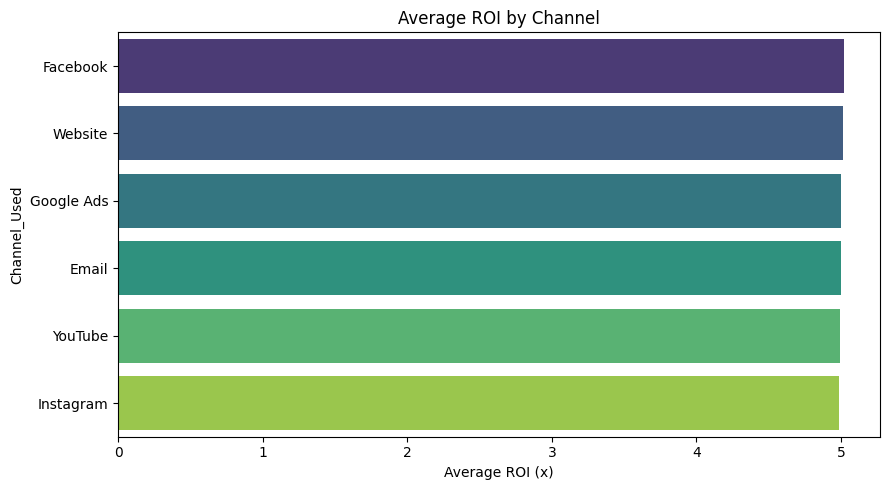

In [7]:
channel_roi = df.groupby("Channel_Used")["ROI"].mean().sort_values(ascending=False)
plt.figure(figsize=(9,5))
sns.barplot(x=channel_roi.values, y=channel_roi.index, palette="viridis")
plt.title("Average ROI by Channel")
plt.xlabel("Average ROI (x)")
plt.tight_layout()
plt.savefig("roi_by_channel.png", dpi=150)
plt.show()

/tmp/ipykernel_3422/856965917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_roi.values, y=type_roi.index, palette="mako")


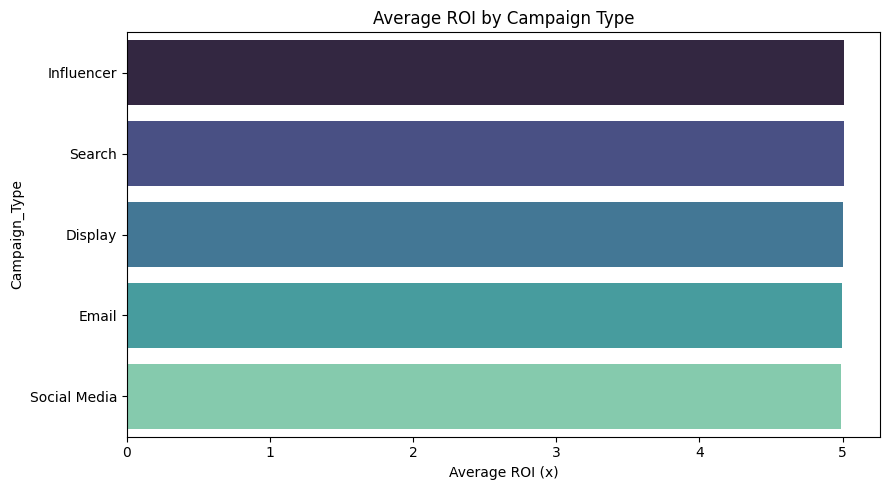

In [8]:
type_roi = df.groupby("Campaign_Type")["ROI"].mean().sort_values(ascending=False)
plt.figure(figsize=(9,5))
sns.barplot(x=type_roi.values, y=type_roi.index, palette="mako")
plt.title("Average ROI by Campaign Type")
plt.xlabel("Average ROI (x)")
plt.tight_layout()
plt.savefig("roi_by_campaign_type.png", dpi=150)
plt.show()

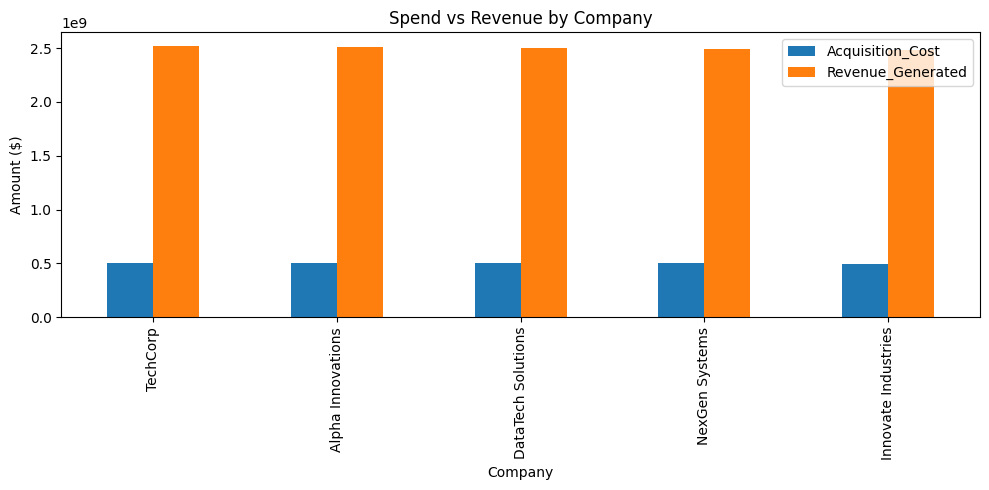

In [9]:
company_summary = df.groupby("Company")[["Acquisition_Cost","Revenue_Generated"]].sum().sort_values("Revenue_Generated", ascending=False)
company_summary.plot(kind="bar", figsize=(10,5))
plt.title("Spend vs Revenue by Company")
plt.ylabel("Amount ($)")
plt.tight_layout()
plt.savefig("spend_vs_revenue_company.png", dpi=150)
plt.show()

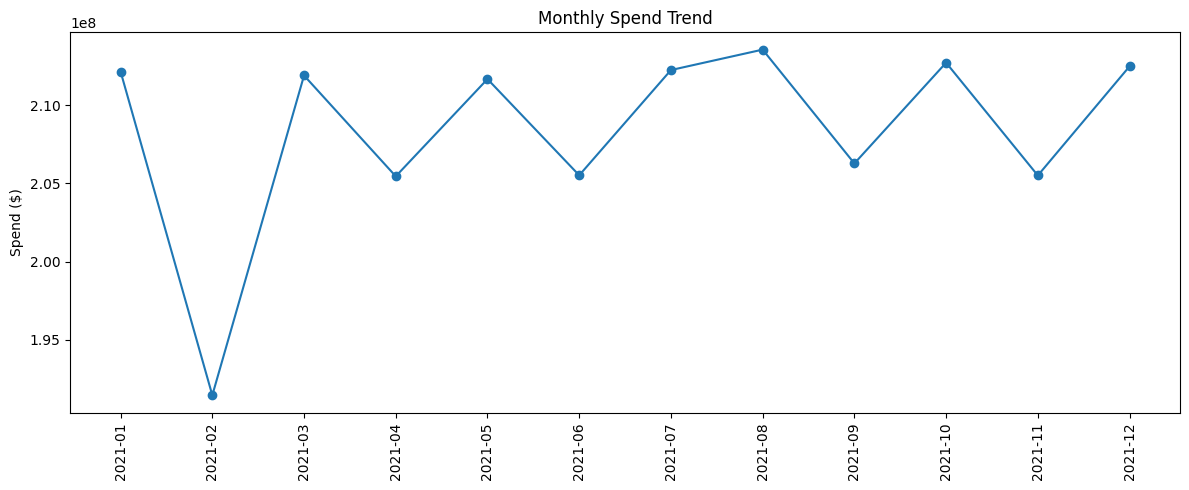

In [10]:
monthly_trend = df.groupby(["Year","Month"])["Acquisition_Cost"].sum().reset_index()
monthly_trend["Period"] = monthly_trend["Year"].astype(str) + "-" + monthly_trend["Month"].astype(str).str.zfill(2)
plt.figure(figsize=(12,5))
plt.plot(monthly_trend["Period"], monthly_trend["Acquisition_Cost"], marker="o")
plt.xticks(rotation=90)
plt.title("Monthly Spend Trend")
plt.ylabel("Spend ($)")
plt.tight_layout()
plt.savefig("monthly_spend_trend.png", dpi=150)
plt.show()

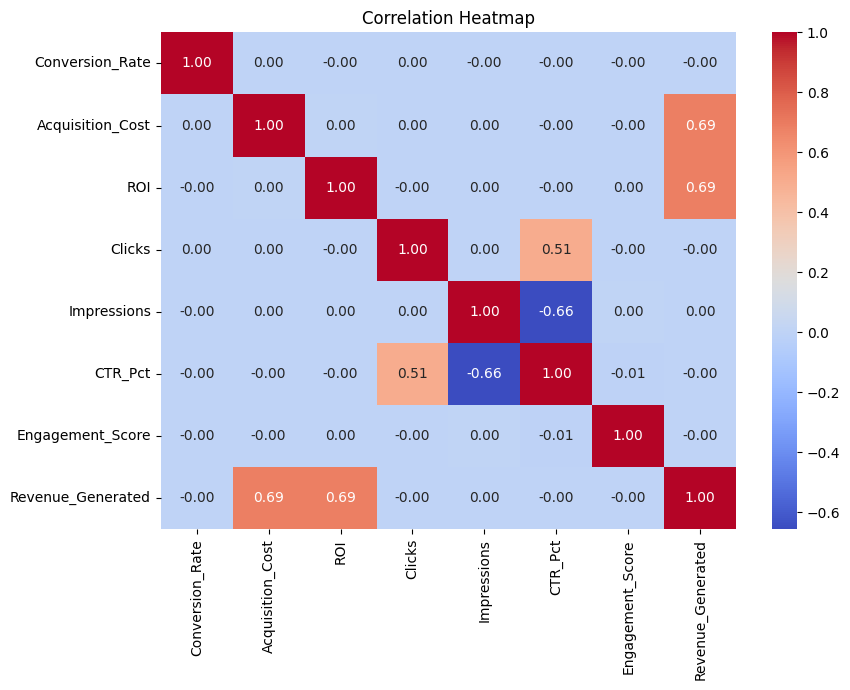

In [11]:
numeric_cols = ["Conversion_Rate","Acquisition_Cost","ROI","Clicks","Impressions","CTR_Pct","Engagement_Score","Revenue_Generated"]
plt.figure(figsize=(9,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [12]:
files.download("roi_by_channel.png")
files.download("roi_by_campaign_type.png")
files.download("spend_vs_revenue_company.png")
files.download("monthly_spend_trend.png")
files.download("correlation_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>